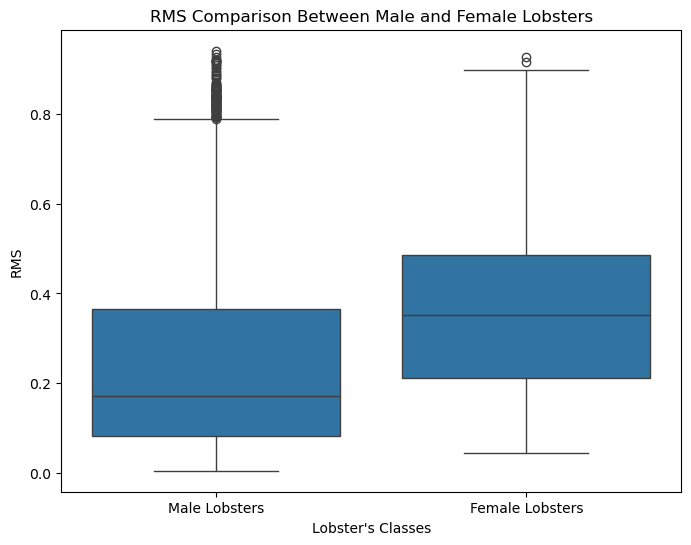

                    RMS                                                    \
                  count      mean       std       min       25%       50%   
Folder                                                                      
Female Lobsters  2900.0  0.357570  0.177726  0.043919  0.210979  0.352948   
Male Lobsters    4407.0  0.252555  0.211430  0.005111  0.083049  0.172640   

                                     
                      75%       max  
Folder                               
Female Lobsters  0.485989  0.926379  
Male Lobsters    0.365161  0.940525  


In [4]:
import librosa
import numpy as np
import matplotlib.pyplot as plt
import os
import pandas as pd
import seaborn as sns

def calculate_rms_and_create_boxplot(audio_folders, folder_names):
    """Calculates RMS for audio segments in multiple folders and creates a box plot.

    Args:
        audio_folders: A list of paths to the audio folders.
        folder_names: A list of names corresponding to each folder (for labels).
    """

    data = []  # List to store RMS values for all folders
    labels = [] # List to store labels for each RMS value

    for i, audio_folder in enumerate(audio_folders):
        rms_values = []
        for filename in os.listdir(audio_folder):
            if filename.endswith(('.wav', '.mp3', '.flac')):
                audio_file = os.path.join(audio_folder, filename)
                try:
                    y, sr = librosa.load(audio_file, duration=1.0) # Load audio

                    if len(y) != sr:
                        print(f"Warning: {filename} in {folder_names[i]} is not exactly 1 second long. It is {len(y)/sr} seconds long")

                    rms = np.sqrt(np.mean(y**2))
                    rms_values.append(rms)

                except Exception as e:
                    print(f"Error processing {filename} in {folder_names[i]}: {e}")
        
        # Add RMS values and labels to the data lists
        data.extend(rms_values)
        labels.extend([folder_names[i]] * len(rms_values)) # Add label for each value in rms_values

    if not data:
        print("No valid audio files found in any of the folders or errors occurred during processing.")
        return

    # Create a Pandas DataFrame for easier plotting with Seaborn
    df = pd.DataFrame({'Folder': labels, 'RMS': data})

    # Create the box plot using Seaborn
    plt.figure(figsize=(8, 6))  # Adjust figure size as needed
    sns.boxplot(x='Folder', y='RMS', data=df)
    plt.xlabel("Lobster's Classes")
    plt.ylabel("RMS")
    plt.title("RMS Comparison Between Male and Female Lobsters")
    plt.show()

    # Print descriptive statistics (optional)
    print(df.groupby('Folder').describe()) # Show statistics for each group

# Example usage with two folders:
audio_folders = [
    "/home/feliciano/male_lobsters",  # Replace with your folder paths
    "/home/feliciano/female_lobsters", # Replace with your folder paths
]
folder_names = ["Male Lobsters", "Female Lobsters"]  # Replace with your folder names

calculate_rms_and_create_boxplot(audio_folders, folder_names)